# SHD single-sample visualization

Trace **one** random spike train from `shd_whole.mat` through the exact
data-processing logic of `shd/shd_data_gen.py` (min-count filtering +
non-zero-neuron masking) to obtain its three versions:

* **whole** &mdash; the raw dense spike train `X_all[idx]`.
* **part**  &mdash; `X_all[idx]` restricted to the surviving neurons (`non_zero_mask`); original spikes, no down-sampling.
* **norm**  &mdash; `X_min[idx]` restricted to those neurons, i.e. the min-count down-sampled spikes.

The full-dataset pipeline is memory-heavy, so we apply the *identical* logic to a
single sample using two exact equivalences:

* `do_min_count` forces every kept sample to hold exactly `N_f = min_counts[f]`
  spikes on neuron `f` (or 0 when `N_f == 0`), so the pipeline's
  `non_zero_mask = X_min.sum(axis=(0, 2)) > 0` is identical to `min_counts > 0`.
* The `norm` spike train for one sample is exactly `do_min_count`'s inner
  per-neuron down-sampling applied to that single sample.

In [1]:
import numpy as np
import scipy.io as io
import matplotlib.pyplot as plt

%matplotlib inline

## Data processing (mirrors `shd_data_gen.py`)

In [2]:
def compute_keep_idxs(
    counts: np.ndarray,
    neuron_threshold: int = 2,
    max_frac_for_neuron: float = 0.01,
    max_samples_to_remove: int = 2000,
) -> np.ndarray:
    """Reproduce the sample-removal logic of ``create_min_count_dataset_return_mask``.

    Args:
        counts: Per-sample, per-neuron spike counts, shape ``(N, F)``.
        neuron_threshold: Minimum acceptable per-neuron count.
        max_frac_for_neuron: Max fraction of samples a bad neuron may drop.
        max_samples_to_remove: Upper bound on total removed samples.

    Returns:
        Indices of the samples that are kept, shape ``(N_kept,)``.
    """
    num_samples, _ = counts.shape
    min_counts_per_neuron = counts.min(axis=0)

    bad_neurons = np.where(min_counts_per_neuron < neuron_threshold)[0]
    print(f"Found {len(bad_neurons)} neurons with min_count < {neuron_threshold}.")

    keep_idxs = np.arange(num_samples)
    if len(bad_neurons) > 0:
        samples_to_remove = set()
        for f_idx in bad_neurons:
            neuron_counts = counts[:, f_idx]
            i_bad = np.where(neuron_counts < neuron_threshold)[0]
            frac = len(i_bad) / num_samples
            if frac <= max_frac_for_neuron:
                samples_to_remove.update(i_bad)

        if 0 < len(samples_to_remove) < max_samples_to_remove:
            keep_idxs = np.setdiff1d(np.arange(num_samples), list(samples_to_remove))
            print(f"Removing {len(samples_to_remove)} samples.")
        else:
            print("NOT removing any samples.")

    return keep_idxs


def min_count_single_sample(spike_train: np.ndarray, min_counts: np.ndarray) -> np.ndarray:
    """Apply ``do_min_count``'s per-neuron down-sampling to one spike train.

    For each neuron ``f`` with ``N_f = min_counts[f] > 0``, keep exactly ``N_f``
    spikes (randomly sub-sampling when the sample has more); neurons with
    ``N_f == 0`` are left empty.

    Args:
        spike_train: Dense spike train for one sample, shape ``(F, T)``.
        min_counts: Per-neuron minimum spike counts over kept samples, shape ``(F,)``.

    Returns:
        The min-count down-sampled spike train, shape ``(F, T)``.
    """
    num_neurons, _ = spike_train.shape
    out = np.zeros_like(spike_train)
    for f_idx in range(num_neurons):
        n_f = min_counts[f_idx]
        if n_f == 0:
            continue
        spike_times = np.where(spike_train[f_idx] == 1)[0]
        if len(spike_times) > n_f:
            chosen_times = np.random.choice(spike_times, size=n_f, replace=False)
            out[f_idx, chosen_times] = 1
        else:
            out[f_idx, spike_times] = 1
    return out

## Plotting helper

In [3]:
def plot_raster(ax: plt.Axes, spike_train: np.ndarray, title: str) -> None:
    """Plot a spike raster for a single sample (neurons x time)."""
    neuron_idxs, time_idxs = np.where(spike_train == 1)
    ax.scatter(time_idxs, neuron_idxs, s=0.5, c="black", marker=".")
    ax.set_title(title)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Neuron index")
    ax.set_xlim(0, spike_train.shape[1])
    ax.set_ylim(0, max(spike_train.shape[0], 1))

## Load, process one random sample, and plot

In [4]:
data_dir = "./shd/shd_data"
whole_path = f"{data_dir}/shd_whole.mat"
seed = 0
num_steps = 100  # SHD dense trains already use 100 time bins

np.random.seed(seed)

# --- Load the whole dense dataset ---
data = io.loadmat(whole_path)
X_all = data["X"]  # (N, 700, 100) uint8
Y_all = data["Y"].ravel()
assert X_all.shape[2] == num_steps, f"expected {num_steps} time steps, got {X_all.shape[2]}"
print(f"Loaded whole dataset: X={X_all.shape}, Y={Y_all.shape}")

Loaded whole dataset: X=(9984, 700, 100), Y=(9984,)


In [5]:
# --- Reproduce the pipeline's masks from per-neuron statistics ---
counts = X_all.sum(axis=2)  # (N, F)
keep_idxs = compute_keep_idxs(counts)

min_counts = counts[keep_idxs].min(axis=0)  # == do_min_count's min_counts
non_zero_mask = min_counts > 0  # == main()'s X_min-based non_zero_mask
print(
    f"Kept samples: {len(keep_idxs)} / {len(Y_all)}; "
    f"surviving neurons: {int(non_zero_mask.sum())} / {X_all.shape[1]}"
)

Found 691 neurons with min_count < 2.
Removing 1037 samples.
Kept samples: 8947 / 9984; surviving neurons: 224 / 700


In [6]:
# --- Pick one random spike train (from the kept set) ---
j = np.random.randint(len(keep_idxs))
real_idx = int(keep_idxs[j])
label = int(Y_all[real_idx])

whole = X_all[real_idx]  # (700, 100)
part = whole[non_zero_mask]  # original spikes on surviving neurons
norm = min_count_single_sample(whole, min_counts)[non_zero_mask]  # min-count version

print(
    f"Sample idx={real_idx}, label={label} | "
    f"spikes whole={int(whole.sum())}, part={int(part.sum())}, norm={int(norm.sum())}"
)

Sample idx=3128, label=10 | spikes whole=5315, part=3803, norm=471


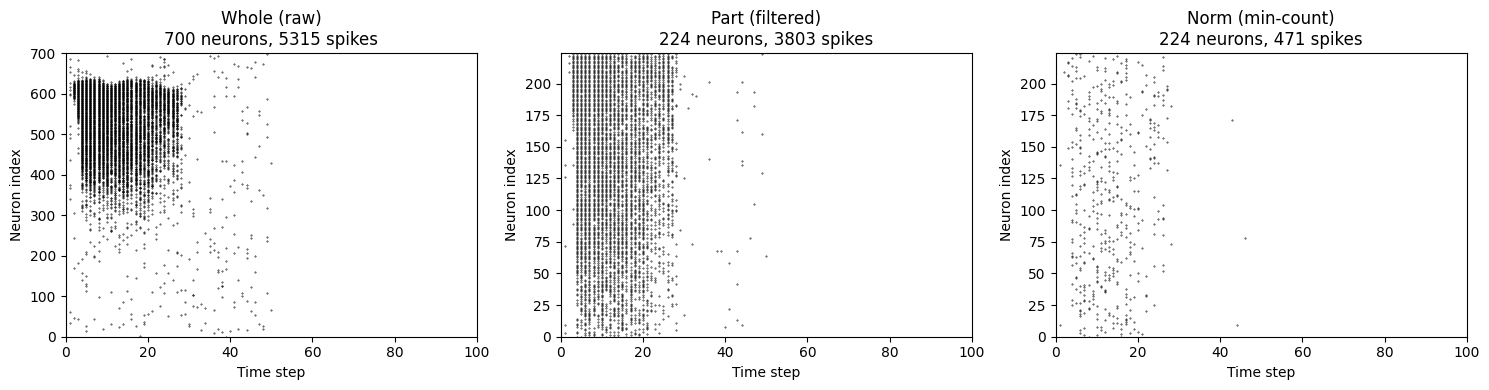

In [9]:
# --- Plot the three versions of the same spike train ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_raster(axes[0], whole, f"Whole (raw)\n{whole.shape[0]} neurons, {int(whole.sum())} spikes")
plot_raster(axes[1], part, f"Part (filtered)\n{part.shape[0]} neurons, {int(part.sum())} spikes")
plot_raster(axes[2], norm, f"Norm (min-count)\n{norm.shape[0]} neurons, {int(norm.sum())} spikes")
#fig.suptitle(f"SHD sample idx={real_idx}, label={label} (seed={seed})", fontsize=13)

fig.tight_layout()
fig.savefig(f"{data_dir}/shd_single_sample_visual.png", dpi=150, bbox_inches="tight")
plt.show()